## ⚙️ Env


In [1]:
import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder

# 📘 Association Analysis

---

## 📚 Introduction
Analisis asosiasi adalah teknik dalam data mining yang digunakan untuk menemukan pola keterkaitan antar variabel dalam suatu dataset. Tujuannya adalah untuk menjawab pertanyaan seperti:

```Jika suatu kejadian A terjadi, seberapa besar kemungkinan kejadian B ikut terjadi?```

**Association Rule Mining** bertujuan menemukan pola `X → Y` di mana X dan Y adalah itemset.

## 📊 Contoh Dataset

In [2]:
data = [
    ['Bread', 'Milk'],
    ['Bread', 'Diaper', 'Beer', 'Eggs'],
    ['Milk', 'Diaper', 'Beer', 'Coke'],
    ['Bread', 'Milk', 'Diaper', 'Beer'],
    ['Bread', 'Milk', 'Diaper', 'Coke']
]
df = pd.DataFrame({'transaction': data})
df.head()


,transaction
0,"[Bread, Milk]"
1,"[Bread, Diaper, Beer, Eggs]"
2,"[Milk, Diaper, Beer, Coke]"
3,"[Bread, Milk, Diaper, Beer]"
4,"[Bread, Milk, Diaper, Coke]"


#### Contingency Table

Saat kita punya sebuah rule:
``X → Y``
kita butuh mengetahui bagaimana X dan Y terjadi bersama atau tidak bersama dalam seluruh transaksi.

Contingency table ini membagi seluruh transaksi ke dalam 4 kategori:

## Contingency Table for X → Y

|            | **Y**  | **Ȳ**  | **Row Total** |
|------------|--------|--------|----------------|
| **X**      | f₁₁    | f₁₀    | f₁⁺            |
| **X̄**      | f₀₁    | f₀₀    | f₀⁺            |
| **Column Total** | f₊₁ | f₊₀ | \|T\|          |


diringkas menjadi:
| Simbol  | Arti                                 |
| ------- | ------------------------------------ |
| **f0+** | semua transaksi yang *tidak punya X* |
| **f+0** | semua transaksi yang *tidak punya Y* |
| **f1+** | semua transaksi yang punya X         |
| **f+1** | semua transaksi yang punya Y         |


contoh:

#### Example Data

- Variable A: {A1, A2}
- Variable B: {B1, B2, B3}

#### Contingency Table

|  | B1 | B2 | B3 | Total |
| -- | ---- | ---- | ---- | ------- |
| **A1** | 10 | 5  | 8  | 23    |
| **A2** | 7  | 12 | 4  | 23    |
| **Total** | 17 | 17 | 12 | 46    |

In [3]:
def contingency_counts(df_ohe, X, Y):
    X_mask = df_ohe[list(X)].all(axis=1) if len(X)>0 else pd.Series([False]*len(df_ohe))
    Y_mask = df_ohe[list(Y)].all(axis=1) if len(Y)>0 else pd.Series([False]*len(df_ohe))
    f11 = (X_mask & Y_mask).sum()
    f10 = (X_mask & ~Y_mask).sum()
    f01 = (~X_mask & Y_mask).sum()
    f00 = (~X_mask & ~Y_mask).sum()
    return f11, f10, f01, f00


### Evaluation Metrics

#### 🟦 1. SUPPORT

Menunjukkan seberapa sering X dan Y muncul bersama di seluruh transaksi.

$ \text{support}(X \rightarrow Y) = P(X,Y) = \frac{f_{11}}{|T|} $

```
support(X → Y) = f11 / |T|
```

Nilai support tinggi = rule muncul sering → pattern penting secara frekuensi.

`` seberapa sering X dan Y terjadi bersama?``

---
#### 🟩 2. CONFIDENCE

Mengukur peluang Y terjadi jika X terjadi.

$ \text{confidence}(X \rightarrow Y) = \frac{f_{11}}{f_{1+}} = P(Y|X) $

```
confidence(X → Y) = f11 / f1+
```
Dimana f1+ = semua transaksi yang mengandung X.

``jika terjadi X maka seberapa besar peluang terjadi Y``

---

#### 🟧 3. LIFT

Lift membandingkan confidence dengan probabilitas Y secara umum.

$ \text{lift}(X \rightarrow Y)
= \frac{P(X,Y)}{P(X)\, P(Y)}
= \frac{\text{confidence}(X\rightarrow Y)}{P(Y)} $

```
lift = confidence / support(Y)
     = (f11 / f1+) / (f+1 / |T|)
```
interpretasi:
- jika > 1 maka X dan Y korelasi positif
- jika = 1 maka X dan Y independent
- jika < 1 maka X dan Y korelasi negatif

``Apakah X dan Y benar benar berkolerasi?``

---

#### 🟪 4. LEVERAGE
Leverage mengukur perbedaan antara support aktual dan support jika independen.

$ \text{leverage}(X,Y) = P(X,Y) - P(X)P(Y) $

```
leverage = P(X,Y) − P(X)P(Y)
         = f11/|T| − (f1+/|T|)*(f+1/|T|)
```
interpretasi:
- 0 → X dan Y independen -> - 0 → X dan Y sering muncul bersama lebih dari ekspektasi

- <0 → muncul bersama kurang dari ekspektasi

---

#### 🟥 5. CONVICTION
Conviction mengukur ketergantungan Y pada X, tapi memfokuskan pada kasus pelanggaran rule (X tanpa Y = f10).

$ \text{conviction}(X \rightarrow Y)
= \frac{1 - P(Y)}{1 - P(Y \mid X)} $
```
conviction = (1 - support(Y)) / (1 - confidence)
```
interpretasi:
- Jika Y jarang terjadi, tapi setiap kali X muncul Y hampir selalu muncul → conviction bisa sangat tinggi.
- X tidak memengaruhi Y sama sekali → X dan Y independen (rule tidak berarti)
- Ketika X muncul, Y malah cenderung tidak muncul

---

#### 🟫 6. PHI COEFFICIENT (Φ)
Phi mengukur korelasi Pearson antara variabel X dan Y (keduanya biner).

$ \phi = \frac{f_{11}f_{00} - f_{10}f_{01}}{\sqrt{ (f_{1+})(f_{0+})(f_{+1})(f_{+0}) }} $

```
phi = (f11*f00 - f10*f01) /
      sqrt(f1+ * f0+ * f+1 * f+0)
```

interpretasi:
- φ > 0 maka X dan Y cenderung muncul bersama
- φ < 0 maka X dan Y menghindari satu sama lain
- φ = 0 maka X dan Y independen

In [4]:
def add_metrics(rules_df, df_ohe):
    rules_df = rules_df.copy()
    n = len(df_ohe)
    metrics = []
    for _, row in rules_df.iterrows():
        X = frozenset(row['antecedents'])
        Y = frozenset(row['consequents'])
        f11,f10,f01,f00 = contingency_counts(df_ohe, X, Y)
        pX = (f11+f10)/n
        pY = (f11+f01)/n
        pXY = f11/n
        # leverage
        leverage = pXY - pX*pY
        # conviction (handle division by zero)
        denom = 1 - (f11/(f11+f10)) if (f11+f10)>0 else np.nan
        conviction = (1 - pY) / denom if denom!=0 else np.inf
        # phi coefficient
        num = f11*f00 - f10*f01
        den = np.sqrt((f11+f10)*(f11+f01)*(f00+f10)*(f00+f01))
        phi = num/den if den>0 else np.nan
        metrics.append((leverage, conviction, phi, f11, f10, f01, f00))
    rules_df[['leverage','conviction','phi','f11','f10','f01','f00']] = pd.DataFrame(metrics, index=rules_df.index)
    return rules_df

### Transformasi: One-hot Encoding (Transaction -> Matriks biner)

In [5]:

te = TransactionEncoder()
te_ary = te.fit(data).transform(data)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
df_encoded


,Beer,Bread,Coke,Diaper,Eggs,Milk
0,False,True,False,False,False,True
1,True,True,False,True,True,False
2,True,False,True,True,False,True
3,True,True,False,True,False,True
4,False,True,True,True,False,True


## 🧠 Apriori — Frequent Itemset & Rules


#### Prinsip Apriori

```Jika sebuah itemset infrequent, maka semua superset-nya pasti infrequent. (Anti-monotone property)```

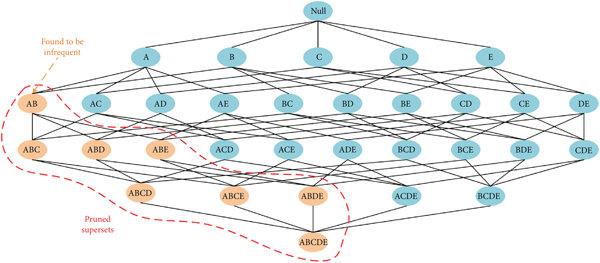

#### Langkah Apriori:

- Temukan frequent 1-itemset

- Buat kandidat k+1 dari frequent k

- Prune kandidat yang subsetnya tidak frequent

- Hitung support

- Simpan yang frequent

- Ulangi sampai tidak ada itemset baru
Contoh penggunaan `apriori` dari mlxtend.


📌 **Kelebihan Apriori**

- Mudah dipahami

- Menghasilkan semua frequent itemset

- Digunakan di banyak textbook dan aplikasi dasar

📌 **Kekurangan Apriori**

- mirip “scan database” (berulang-ulang)

- Jumlah kandidat bisa meledak (explosive)

- Tidak efisien untuk dataset besar dan lebar

In [6]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df_encoded, min_support=0.1, use_colnames=True)

print(frequent_itemsets)


    support                     itemsets
0       0.6                       (Beer)
1       0.8                      (Bread)
2       0.4                       (Coke)
3       0.8                     (Diaper)
4       0.2                       (Eggs)
5       0.8                       (Milk)
6       0.4                (Beer, Bread)
7       0.2                 (Coke, Beer)
8       0.6               (Diaper, Beer)
9       0.2                 (Eggs, Beer)
10      0.4                 (Beer, Milk)
11      0.2                (Coke, Bread)
12      0.6              (Diaper, Bread)
13      0.2                (Eggs, Bread)
14      0.6                (Bread, Milk)
15      0.4               (Coke, Diaper)
16      0.4                 (Coke, Milk)
17      0.2               (Diaper, Eggs)
18      0.6               (Diaper, Milk)
19      0.4        (Diaper, Beer, Bread)
20      0.2          (Eggs, Beer, Bread)
21      0.2          (Beer, Bread, Milk)
22      0.2         (Coke, Beer, Diaper)
23      0.2     

### Rules Generation (Apriori)

In [20]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
ruleDf = pd.DataFrame(rules[['antecedents','consequents', 'support','confidence','lift']])
ruleDf

,antecedents,consequents,support,confidence,lift
0,(Butter),(Bread),0.2465,0.567319,1.008567
1,(Cheese),(Bread),0.1165,0.600515,1.067583
2,(Chicken),(Bread),0.2460,0.607407,1.079835
3,(Coffee),(Bread),0.1540,0.560000,0.995556
4,(Eggs),(Bread),0.1655,0.601818,1.069899
5,(Milk),(Bread),0.1155,0.563415,1.001626
6,(Rice),(Bread),0.1910,0.569300,1.012088
7,(Sugar),(Bread),0.2295,0.564576,1.003690
8,(Tea),(Bread),0.2395,0.551208,0.979926
9,"(Butter, Cheese)",(Bread),0.0520,0.615385,1.094017


In [22]:
rules_ext = add_metrics(rules, df_encoded)
rules_ext[['antecedents','consequents','leverage','conviction','phi','f11','f10', 'f00', 'f01']]


,antecedents,consequents,leverage,conviction,phi,f11,f10,f00,f01
0,(Butter),(Bread),0.002094,1.011137,0.008515,493,376,499,632
1,(Cheese),(Bread),0.007375,1.095161,0.037596,233,155,720,892
2,(Chicken),(Bread),0.018187,1.114387,0.074686,492,318,557,633
3,(Coffee),(Bread),-0.000688,0.994318,-0.003104,308,242,633,817
4,(Eggs),(Bread),0.010813,1.098744,0.048814,331,219,656,794
5,(Milk),(Bread),0.000188,1.002095,0.000936,231,179,696,894
6,(Rice),(Bread),0.002281,1.015787,0.009739,382,289,586,743
7,(Sugar),(Bread),0.000844,1.004767,0.003463,459,354,521,666
8,(Tea),(Bread),-0.004906,0.974840,-0.019952,479,390,485,646
9,"(Butter, Cheese)",(Bread),0.004469,1.137500,0.032388,104,65,810,1021


## ⚡ FP-Growth — Alternatif yang lebih cepat untuk dataset besar

FP-Growth adalah algoritma yang dikembangkan untuk mengatasi kelemahan Apriori, terutama masalah pembuatan kandidat dan scan database yang berulang.
FP-Growth mengatasi ini dengan:

- Membangun FP-Tree

- Melakukan divide-and-conquer dari conditional pattern base

- minusnya ia tidak membangkitkan kandidat sebanyak Apriori.

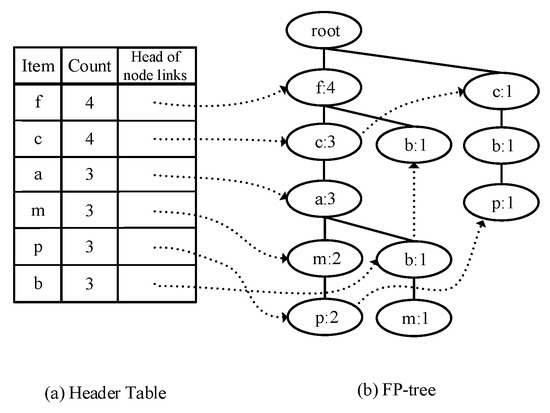

Daripada membangkitkan kandidat itemset seperti Apriori, FP-Growth:

- Mengompres database menjadi struktur tree (FP-Tree)

- Mencari frequent itemset dengan divide-and-conquer tanpa membuat kandidat sebanyak Apriori

#### Langkah FP-Growth
1. Hitung support item dan pilih frequent items Sort item berdasarkan support (descending).

2. Bangun FP-Tree Untuk setiap transaksi: sortir item tergantung urutan frequent item masukkan ke dalam tree tingkatkan count jika jalur sudah ada

3. Buat “Conditional Pattern Base” Semacam database kecil untuk setiap item.

4. Buat Conditional FP-Tree dari pattern base sebelumnya.

5. Rekursi untuk menemukan frequent itemset tanpa membangkitkan semua kandidat.

📌 **Kelebihan FP-Growth**

- Tidak membangkitkan kandidat (lebih cepat dari Apriori)

- Database hanya discan dua kali

- Efektif untuk: dataset besar & transaksi panjang

📌 **Kekurangan FP-Growth**

- Struktur FP-tree lebih sulit dipahami

- Lebih rumit untuk diimplementasikan dari nol

In [9]:
from mlxtend.frequent_patterns import fpgrowth

fp_frequent = fpgrowth(df_encoded, min_support=0.4, use_colnames=True)

rules_fp = association_rules(fp_frequent, metric="confidence", min_threshold=0.5)

ruleDf = pd.DataFrame(rules_fp[['antecedents','consequents','support','confidence','lift']])
ruleDf

,antecedents,consequents,support,confidence,lift
0,(Bread),(Milk),0.6,0.750000,0.937500
1,(Milk),(Bread),0.6,0.750000,0.937500
2,(Diaper),(Bread),0.6,0.750000,0.937500
3,(Bread),(Diaper),0.6,0.750000,0.937500
4,"(Diaper, Bread)",(Milk),0.4,0.666667,0.833333
5,"(Diaper, Milk)",(Bread),0.4,0.666667,0.833333
6,"(Bread, Milk)",(Diaper),0.4,0.666667,0.833333
7,(Diaper),"(Bread, Milk)",0.4,0.500000,0.833333
8,(Bread),"(Diaper, Milk)",0.4,0.500000,0.833333
9,(Milk),"(Diaper, Bread)",0.4,0.500000,0.833333


In [10]:
rules_ext = add_metrics(rules_fp, df_encoded)
rules_ext[['antecedents','consequents','leverage','conviction','phi','f11']]


,antecedents,consequents,leverage,conviction,phi,f11
0,(Bread),(Milk),-0.04,0.8,-0.250000,3
1,(Milk),(Bread),-0.04,0.8,-0.250000,3
2,(Diaper),(Bread),-0.04,0.8,-0.250000,3
3,(Bread),(Diaper),-0.04,0.8,-0.250000,3
4,"(Diaper, Bread)",(Milk),-0.08,0.6,-0.408248,2
5,"(Diaper, Milk)",(Bread),-0.08,0.6,-0.408248,2
6,"(Bread, Milk)",(Diaper),-0.08,0.6,-0.408248,2
7,(Diaper),"(Bread, Milk)",-0.08,0.8,-0.408248,2
8,(Bread),"(Diaper, Milk)",-0.08,0.8,-0.408248,2
9,(Milk),"(Diaper, Bread)",-0.08,0.8,-0.408248,2


## ✍️ Latihan

Disediakan sebuah Dataset yang dibangkitkan secara random, dan coba olah data tersebut sesuai arahan berikut:

1. Jalankan Apriori dan FP-Growth pada dataset sintetik dengan `min_support=0.03` dan `min_confidence=0.7`. Tampilkan 10 aturan teratas menurut lift.
2. Pilih satu aturan dan hitung contingency table (f11,f10,f01,f00) manual, lalu bandingkan dengan output fungsi `add_metrics`.
3. Jelaskan apakah aturan tersebut actionable dan apakah mungkin ada confounding (apakah rule ini mungkin hanya korelasi?).

note: jangan lupa pakai one-hot encoding


In [11]:
import random
import pandas as pd

random.seed(42)
items = ["Bread", "Milk", "Eggs", "Butter", "Cheese",
         "Coffee", "Tea", "Sugar", "Rice", "Chicken"]

def make_random_rules(num_rules=3):
    rules = []
    for _ in range(num_rules):
        pair = random.sample(items, random.randint(1, 2))
        prob = random.uniform(0.05, 0.40)
        rules.append((pair, prob))
    return rules

random_rules = make_random_rules()

item_prob = {item: random.uniform(0.05, 0.50) for item in items}

def generate_transaction():
    t = []

    for pair, prob in random_rules:
        if random.random() < prob:
            t += pair

    for item in items:
        if random.random() < item_prob[item]:
            t.append(item)

    extra_n = random.randint(0, 3)
    t += random.sample(items, extra_n)

    return list(set(t))

transactions = [generate_transaction() for _ in range(2000)]
transactions


[['Coffee', 'Rice', 'Butter', 'Tea', 'Milk'],
 ['Coffee', 'Chicken', 'Butter', 'Eggs', 'Bread'],
 ['Butter', 'Chicken', 'Tea', 'Bread'],
 ['Tea', 'Rice', 'Chicken', 'Bread'],
 ['Rice', 'Butter', 'Eggs', 'Cheese', 'Bread'],
 ['Coffee'],
 ['Butter', 'Rice', 'Tea', 'Bread'],
 ['Sugar', 'Rice', 'Bread'],
 ['Sugar', 'Tea'],
 ['Butter', 'Eggs', 'Tea', 'Milk', 'Bread'],
 ['Eggs', 'Chicken', 'Tea', 'Bread'],
 ['Sugar', 'Chicken', 'Butter', 'Tea', 'Bread'],
 ['Rice', 'Chicken', 'Bread'],
 ['Sugar', 'Tea', 'Bread'],
 ['Sugar', 'Coffee', 'Tea', 'Bread'],
 ['Coffee', 'Sugar', 'Rice', 'Chicken', 'Eggs', 'Cheese', 'Bread'],
 ['Sugar', 'Rice', 'Tea', 'Bread'],
 ['Eggs', 'Rice', 'Tea', 'Bread'],
 ['Butter', 'Bread'],
 ['Butter', 'Sugar', 'Tea', 'Chicken'],
 ['Sugar', 'Rice', 'Chicken', 'Cheese', 'Milk', 'Bread'],
 ['Coffee', 'Chicken', 'Tea'],
 ['Butter'],
 ['Eggs', 'Tea', 'Cheese'],
 ['Chicken', 'Butter'],
 ['Butter', 'Chicken', 'Tea', 'Bread'],
 ['Rice', 'Chicken', 'Butter', 'Bread'],
 ['Sugar', 'Bu

In [12]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
df_encoded

,Bread,Butter,Cheese,Chicken,Coffee,Eggs,Milk,Rice,Sugar,Tea
0,False,True,False,False,True,False,True,True,False,True
1,True,True,False,True,True,True,False,False,False,False
2,True,True,False,True,False,False,False,False,False,True
3,True,False,False,True,False,False,False,True,False,True
4,True,True,True,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1995,True,False,False,False,True,True,False,False,False,False
1996,True,False,False,True,False,False,False,False,False,True
1997,True,False,False,False,False,False,True,True,True,True
1998,False,True,False,True,True,False,False,True,False,True


In [13]:
frequent_itemsets = apriori(df_encoded, min_support=0.03, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.5625,(Bread)
1,0.4345,(Butter)
2,0.1940,(Cheese)
3,0.4050,(Chicken)
4,0.2750,(Coffee)
...,...,...
138,0.0375,"(Sugar, Tea, Butter, Bread)"
139,0.0405,"(Sugar, Rice, Chicken, Bread)"
140,0.0325,"(Rice, Chicken, Tea, Bread)"
141,0.0470,"(Sugar, Tea, Chicken, Bread)"


In [23]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
ruleDf = pd.DataFrame(rules[['antecedents','consequents', 'support','confidence','lift']])
ruleDf

,antecedents,consequents,support,confidence,lift
0,"(Sugar, Rice, Chicken)",(Bread),0.0405,0.704348,1.252174


In [15]:
df = ruleDf[ruleDf['confidence'] >= 0.7]

In [16]:
df

,antecedents,consequents,support,confidence,lift
18,"(Sugar, Rice, Chicken)",(Bread),0.0405,0.704348,1.252174


In [17]:
rules_ext = add_metrics(df, df_encoded)
rules_ext[['antecedents','consequents','leverage','conviction','phi','f11']]

,antecedents,consequents,leverage,conviction,phi,f11
18,"(Sugar, Rice, Chicken)",(Bread),0.008156,1.479779,0.070626,81
